In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel("./data/시도별_전출입_인구수.xlsx", header=0)

print(df.head())


   전출지별   전입지별      1970      1971      1972      1973      1974      1975  \
0  전출지별   전입지별  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1    전국     전국   4046536   4210164   3687938   4860418   5297969   9011440   
2   NaN  서울특별시   1742813   1671705   1349333   1831858   2050392   3396662   
3   NaN  부산광역시    448577    389797    362202    482061    680984    805979   
4   NaN  대구광역시         -         -         -         -         -         -   

       1976      1977  ...      2008      2009      2010      2011      2012  \
0  이동자수 (명)  이동자수 (명)  ...  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1   6773250   7397623  ...   8808256   8487275   8226594   8127195   7506691   
2   2756510   2893403  ...   2025358   1873188   1733015   1721748   1555281   
3    724664    785117  ...    514502    519310    519334    508043    461042   
4         -         -  ...    409938    398626    370817    370563    348642   

       2013      2014      2015      2016      201

In [2]:
# 누락값을 앞데이터를 채움

df = df.ffill()
print(df.head())

   전출지별   전입지별      1970      1971      1972      1973      1974      1975  \
0  전출지별   전입지별  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1    전국     전국   4046536   4210164   3687938   4860418   5297969   9011440   
2    전국  서울특별시   1742813   1671705   1349333   1831858   2050392   3396662   
3    전국  부산광역시    448577    389797    362202    482061    680984    805979   
4    전국  대구광역시         -         -         -         -         -         -   

       1976      1977  ...      2008      2009      2010      2011      2012  \
0  이동자수 (명)  이동자수 (명)  ...  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1   6773250   7397623  ...   8808256   8487275   8226594   8127195   7506691   
2   2756510   2893403  ...   2025358   1873188   1733015   1721748   1555281   
3    724664    785117  ...    514502    519310    519334    508043    461042   
4         -         -  ...    409938    398626    370817    370563    348642   

       2013      2014      2015      2016      201

In [3]:
mask = (df['전출지별'] == '서울특별시') & (df['전입지별'] != '서울특별시') 
df_seoul = df[mask]
df_seoul = df_seoul.drop(['전출지별'], axis=1)
df_seoul = df_seoul.rename({'전입지별':'전입지'}, axis=1)
df_seoul = df_seoul.set_index('전입지')
print(df_seoul.head())

          1970     1971     1972     1973     1974     1975     1976     1977  \
전입지                                                                             
전국     1448985  1419016  1210559  1647268  1819660  2937093  2495620  2678007   
부산광역시    11568    11130    11768    16307    22220    27515    23732    27213   
대구광역시        -        -        -        -        -        -        -        -   
인천광역시        -        -        -        -        -        -        -        -   
광주광역시        -        -        -        -        -        -        -        -   

          1978     1979  ...     2008     2009     2010     2011     2012  \
전입지                      ...                                                
전국     3028911  2441242  ...  2083352  1925452  1848038  1834806  1658928   
부산광역시    29856    28542  ...    17353    17738    17418    18816    16135   
대구광역시        -        -  ...     9720    10464    10277    10397    10135   
인천광역시        -        -  ...    50493    45392 

In [4]:
sr_one = df_seoul.loc['경기도']
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

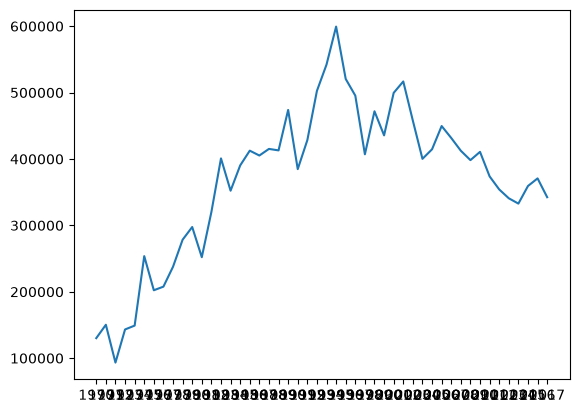

In [5]:
plt.plot(sr_one.index, sr_one.values)

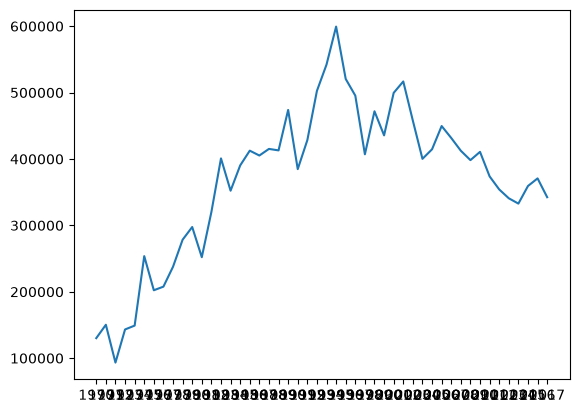

In [6]:
plt.plot(sr_one)
plt.show()

C:\Users\KDS-22\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KDS-22\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KDS-22\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KDS-22\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\KDS-22\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 4

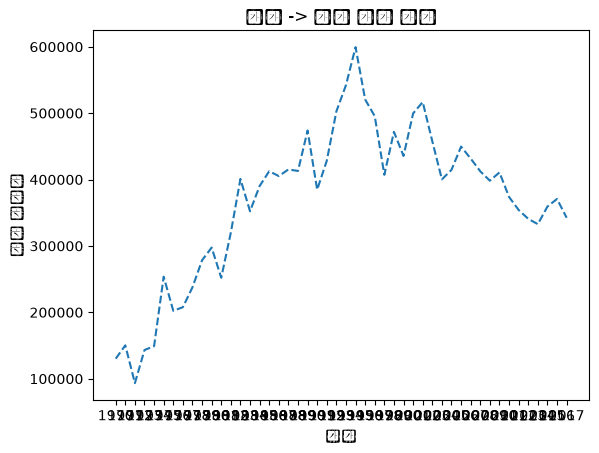

In [7]:
## 차트 제목, 축 이름 추가, 선 스타일 지정

plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.show()

In [8]:
# 한글 폰트 오류 해결

from matplotlib import font_manager, rc
font_path = ("./data/malgun.ttf")
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)

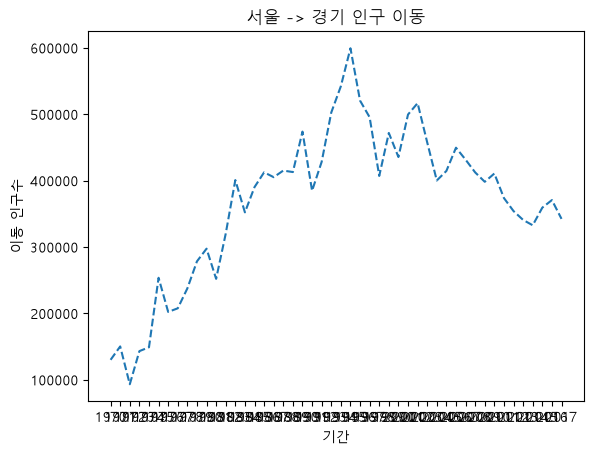

In [9]:
plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.show()

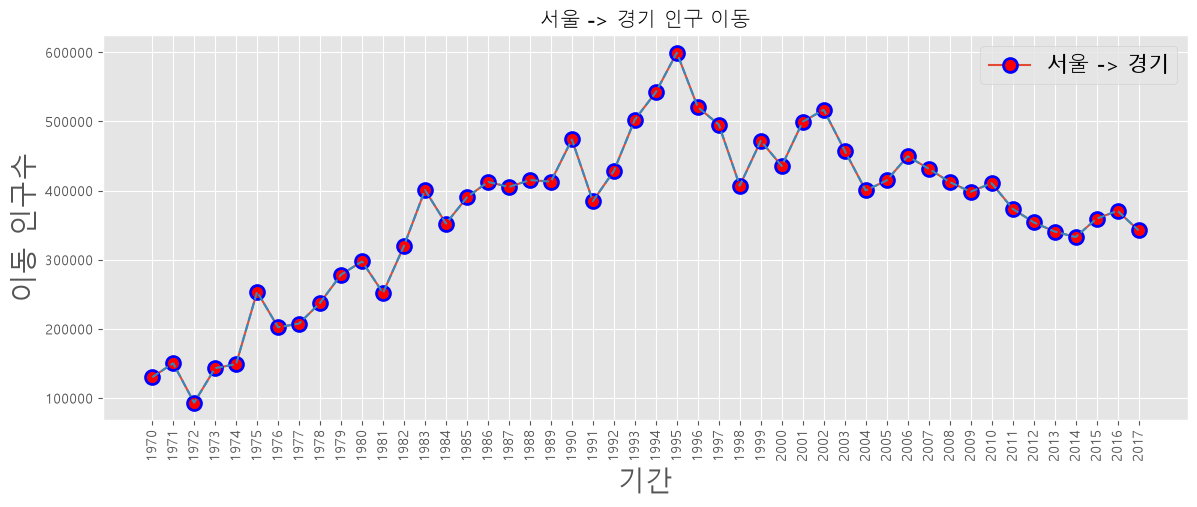

In [10]:
plt.style.use("ggplot")

plt.figure(figsize=(14, 5))

plt.xticks(size=10, rotation="vertical")
plt.plot(
    sr_one.index, sr_one.values,
    marker="o",
    markerfacecolor="red",
    markeredgecolor="blue",
    markeredgewidth=2,
    markersize=10
)

plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("서울 -> 경기 인구 이동")
plt.xlabel("기간", size=20)
plt.ylabel("이동 인구수", size=20)

plt.legend(labels=["서울 -> 경기"], loc="best", fontsize=15)


plt.show()

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

samsung_revenue = pd.read_csv("./data/삼성전자_분기별_매출액.csv")
samsung_revenue = samsung_revenue.sort_values("quarter")

print(samsung_revenue.head())

            value  quarter
5  77203607000000  2022-Q2
4  76781680000000  2022-Q3
3  70464575000000  2022-Q4
2  63745371000000  2023-Q1
1  60005533000000  2023-Q2


In [12]:
fig = plt.figure()
print(fig)

Figure(640x480)


<Figure size 640x480 with 0 Axes>

Figure(640x480)
Axes(0.125,0.11;0.775x0.77)


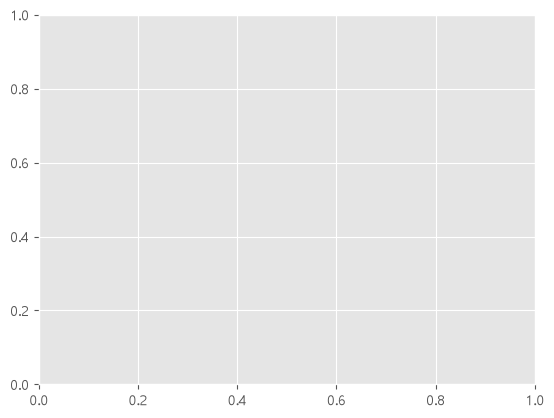

In [13]:
fig, axe = plt.subplots()
print(fig)
print(axe)

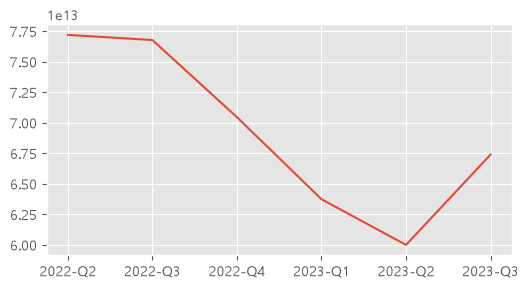

In [14]:
fig, axe = plt.subplots(figsize=(6,3))
axe.plot(samsung_revenue["quarter"], samsung_revenue["value"])
plt.show()

Figure(640x480)
[<Axes: > <Axes: >]


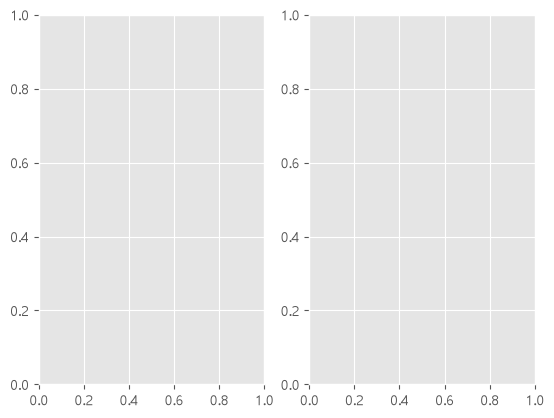

In [15]:
fig, axes = plt.subplots(1, 2)

print(fig)
print(axes)

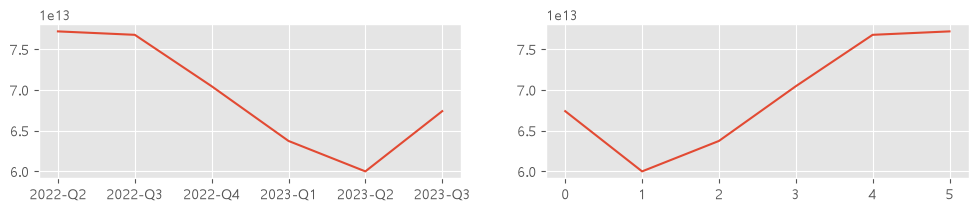

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

axes[0].plot(samsung_revenue["quarter"], samsung_revenue["value"])
samsung_revenue["value"].plot(ax=axes[1])

plt.show()


Figure(640x480)
[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


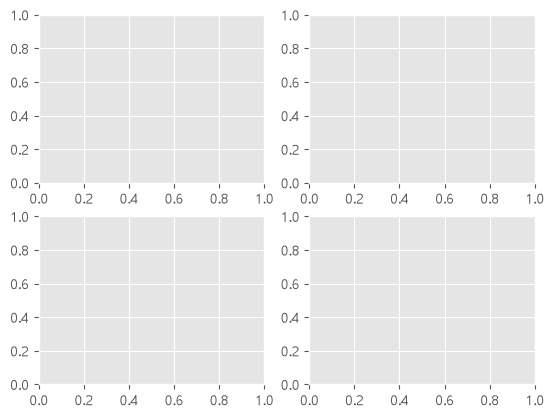

In [18]:
fig, axes = plt.subplots(2, 2)
print(fig)
print(axes)

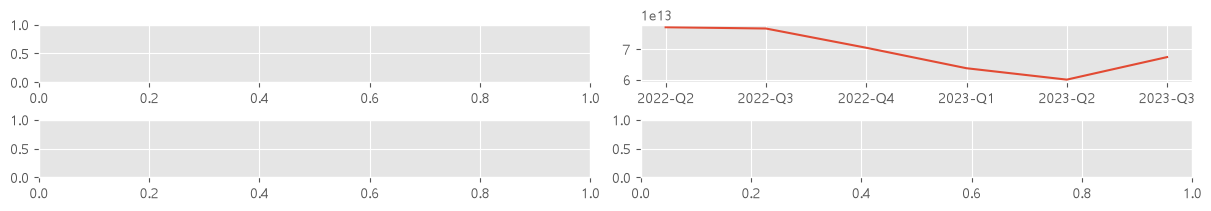

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 2), constrained_layout=True)
axes[0, 1].plot(samsung_revenue["quarter"], samsung_revenue["value"])
plt.show()

In [ ]:
samsung_revenue

,value,quarter
5,77203607000000,2022-Q2
4,76781680000000,2022-Q3
3,70464575000000,2022-Q4
2,63745371000000,2023-Q1
1,60005533000000,2023-Q2
0,67404652000000,2023-Q3


Figure(640x480)
{'top_left': <Axes: label='top_left'>, 'right': <Axes: label='right'>, 'bottom_left': <Axes: label='bottom_left'>}


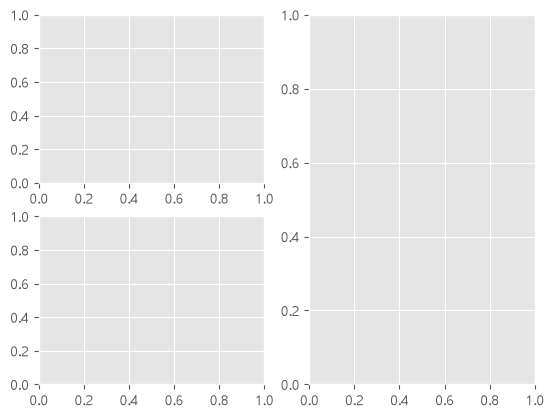

In [22]:
fig, axes = plt.subplot_mosaic([
    ["top_left", "right"],
    ["bottom_left", "right"]
])

print(fig)
print(axes)

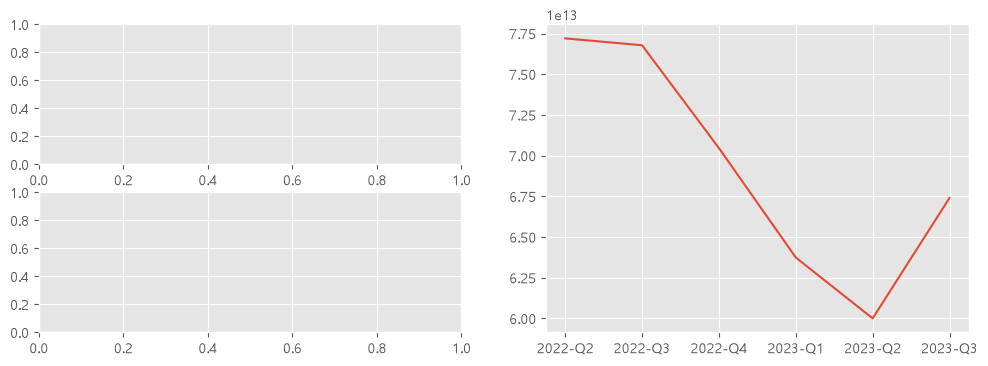

In [25]:
fig, axes = plt.subplot_mosaic([
    ["top_left", "right"],
    ["bottom_left", "right"]
], figsize=(12, 4))

axes["right"].plot(samsung_revenue["quarter"], samsung_revenue["value"])
plt.show()


In [27]:
sr_one.head()

1970    130149
1971    150313
1972     93333
1973    143234
1974    149045
Name: 경기도, dtype: object

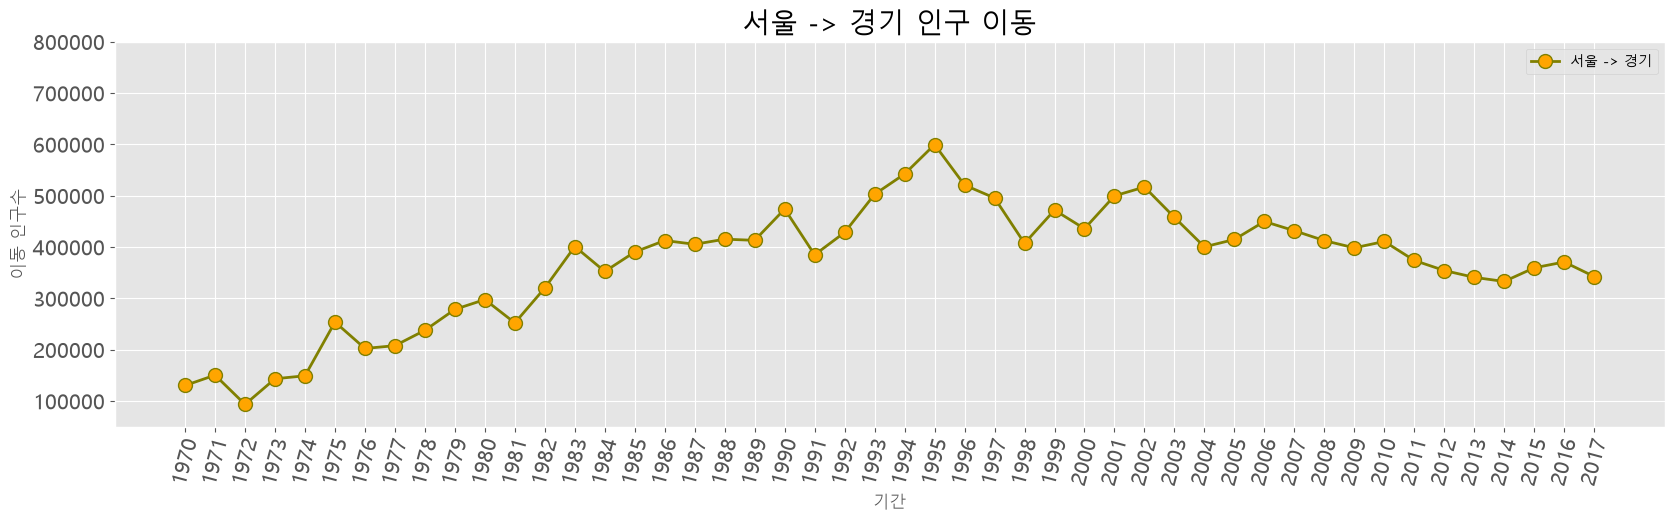

In [46]:
plt.style.use("ggplot")

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(
    sr_one,
    marker="o",
    markerfacecolor="orange",
    markersize=10,
    color="olive",
    linewidth=2,
    label="서울 -> 경기"
    )

ax.legend(loc="best")
ax.set_ylim(50000, 800000)

ax.set_title("서울 -> 경기 인구 이동", size = 20)

ax.set_xlabel("기간", size=12)
ax.set_ylabel("이동 인구수", size=12)

ax.set_xticks(sr_one.index)
ax.set_xticklabels(sr_one.index, rotation=75)

ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=15)

C:\Users\KDS-22\AppData\Local\Temp\ipykernel_26580\1132263034.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(col_years, rotation=90)


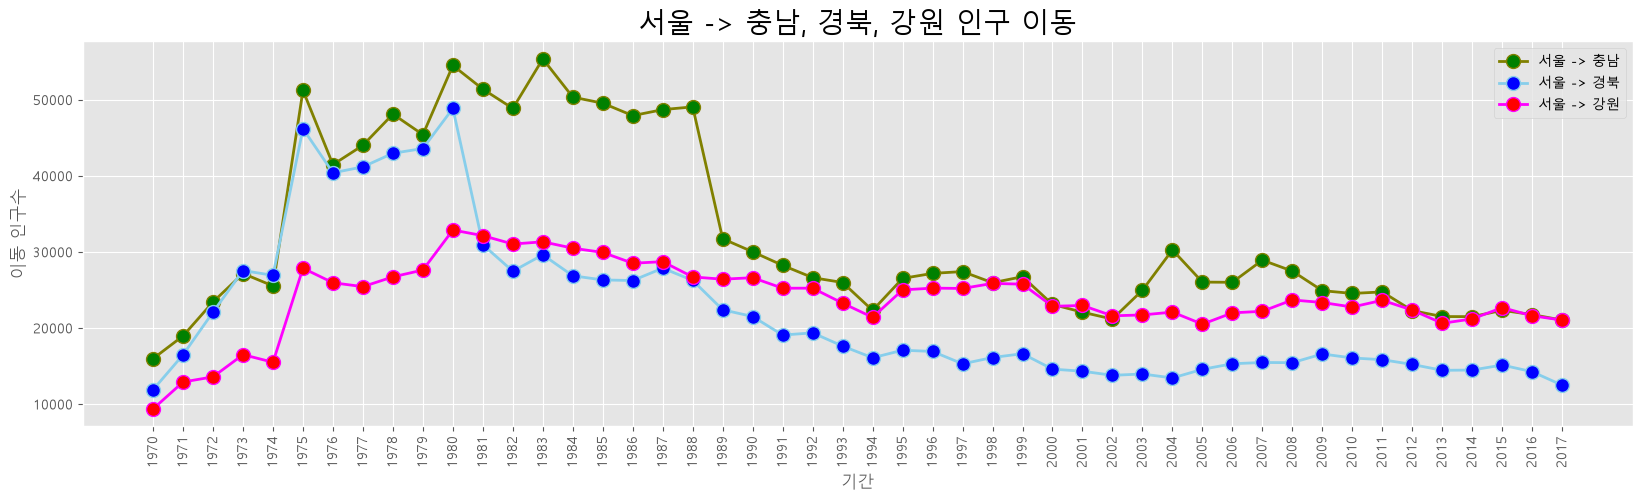

In [57]:
col_years = list(map(str, range(1970, 2018)))

df_3 = df_seoul.loc[["충청남도", "경상북도", "강원도"], col_years]
df_3

fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(1, 1, 1)

ax.plot(col_years, df_3.loc["충청남도"], 
        marker="o",
        markerfacecolor="green",
        markersize=10,
        color="olive",
        linewidth=2,
        label="서울 -> 충남"
        )

ax.plot(col_years, df_3.loc["경상북도"], 
        marker="o", 
        markerfacecolor="blue",
        markersize=10,
        color="skyblue",
        linewidth=2,
        label="서울 -> 경북"
        )

ax.plot(col_years, df_3.loc["강원도"], 
        marker="o", 
        markerfacecolor="red",
        markersize=10,
        color="magenta",
        linewidth=2,
        label="서울 -> 강원"
        )

ax.legend(loc="best")

ax.set_title("서울 -> 충남, 경북, 강원 인구 이동", size=20)
ax.set_xlabel("기간", size=12)
ax.set_ylabel("이동 인구수", size=12)

ax.set_xticklabels(col_years, rotation=90)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

plt.show()

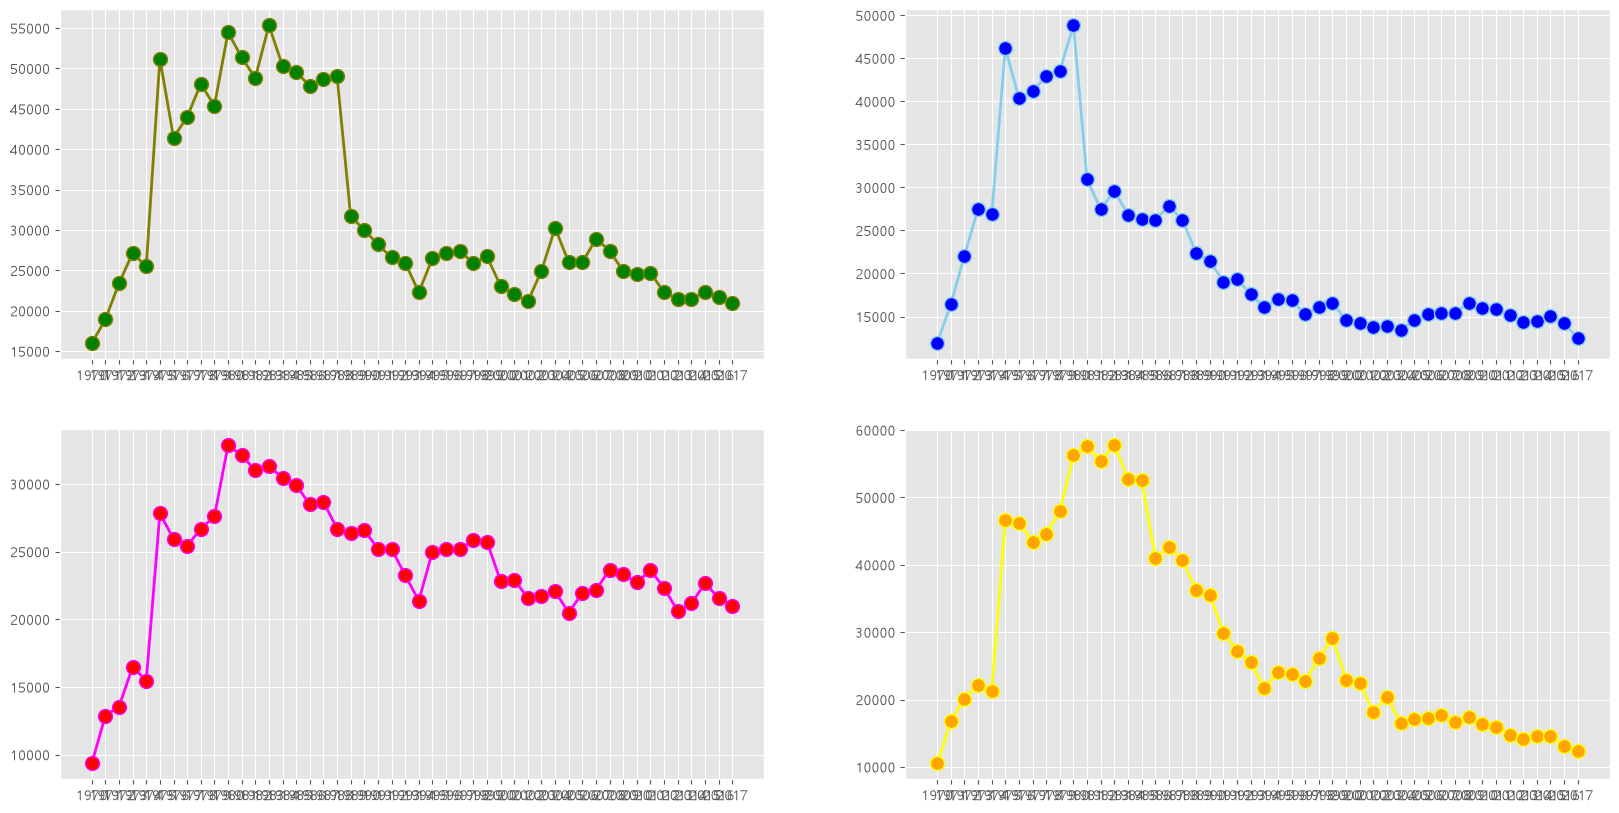

In [65]:
col_years = list(map(str, range(1970, 2018)))

df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]
df_4

# fig = plt.figure(figsize=(20, 5))
# ax = fig.add_subplot(1, 1, 1)

plt.style.use("ggplot")

fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

ax1.plot(col_years, df_4.loc["충청남도", :],
        marker="o",
        markerfacecolor="green",
        markersize=10,
        color="olive",
        linewidth=2,
        label="서울 -> 충남" 
        )

ax2.plot(col_years, df_4.loc["경상북도"], 
        marker="o", 
        markerfacecolor="blue",
        markersize=10,
        color="skyblue",
        linewidth=2,
        label="서울 -> 경북"
    )

ax3.plot(col_years, df_4.loc["강원도"], 
        marker="o", 
        markerfacecolor="red",
        markersize=10,
        color="magenta",
        linewidth=2,
        label="서울 -> 강원"
    
)
ax4.plot(col_years, df_4.loc["전라남도"], 
        marker="o", 
        markerfacecolor="orange",
        markersize=10,
        color="yellow",
        linewidth=2,
        label="서울 -> 전남"
    
)



In [68]:
# matplotlib 에서 사용할 수 있는 색의 종류

import matplotlib

colors = {}

for name, hex in matplotlib.colors.cnames.items():
    colors[name] = hex

print(colors)
print(len(colors))

{'aliceblue': '#F0F8FF', 'antiquewhite': '#FAEBD7', 'aqua': '#00FFFF', 'aquamarine': '#7FFFD4', 'azure': '#F0FFFF', 'beige': '#F5F5DC', 'bisque': '#FFE4C4', 'black': '#000000', 'blanchedalmond': '#FFEBCD', 'blue': '#0000FF', 'blueviolet': '#8A2BE2', 'brown': '#A52A2A', 'burlywood': '#DEB887', 'cadetblue': '#5F9EA0', 'chartreuse': '#7FFF00', 'chocolate': '#D2691E', 'coral': '#FF7F50', 'cornflowerblue': '#6495ED', 'cornsilk': '#FFF8DC', 'crimson': '#DC143C', 'cyan': '#00FFFF', 'darkblue': '#00008B', 'darkcyan': '#008B8B', 'darkgoldenrod': '#B8860B', 'darkgray': '#A9A9A9', 'darkgreen': '#006400', 'darkgrey': '#A9A9A9', 'darkkhaki': '#BDB76B', 'darkmagenta': '#8B008B', 'darkolivegreen': '#556B2F', 'darkorange': '#FF8C00', 'darkorchid': '#9932CC', 'darkred': '#8B0000', 'darksalmon': '#E9967A', 'darkseagreen': '#8FBC8F', 'darkslateblue': '#483D8B', 'darkslategray': '#2F4F4F', 'darkslategrey': '#2F4F4F', 'darkturquoise': '#00CED1', 'darkviolet': '#9400D3', 'deeppink': '#FF1493', 'deepskyblue'

In [70]:
# 면적 그래프

df_4.head()
df_4.info()

<class 'pandas.DataFrame'>
Index: 4 entries, 충청남도 to 전라남도
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   1970    4 non-null      object
 1   1971    4 non-null      object
 2   1972    4 non-null      object
 3   1973    4 non-null      object
 4   1974    4 non-null      object
 5   1975    4 non-null      object
 6   1976    4 non-null      object
 7   1977    4 non-null      object
 8   1978    4 non-null      object
 9   1979    4 non-null      object
 10  1980    4 non-null      object
 11  1981    4 non-null      object
 12  1982    4 non-null      object
 13  1983    4 non-null      object
 14  1984    4 non-null      object
 15  1985    4 non-null      object
 16  1986    4 non-null      object
 17  1987    4 non-null      object
 18  1988    4 non-null      object
 19  1989    4 non-null      object
 20  1990    4 non-null      object
 21  1991    4 non-null      object
 22  1992    4 non-null      object
 23  1993

In [73]:
df_4 = df_4.astype(int)
df_4.info()

<class 'pandas.DataFrame'>
Index: 4 entries, 충청남도 to 전라남도
Data columns (total 48 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   1970    4 non-null      int64
 1   1971    4 non-null      int64
 2   1972    4 non-null      int64
 3   1973    4 non-null      int64
 4   1974    4 non-null      int64
 5   1975    4 non-null      int64
 6   1976    4 non-null      int64
 7   1977    4 non-null      int64
 8   1978    4 non-null      int64
 9   1979    4 non-null      int64
 10  1980    4 non-null      int64
 11  1981    4 non-null      int64
 12  1982    4 non-null      int64
 13  1983    4 non-null      int64
 14  1984    4 non-null      int64
 15  1985    4 non-null      int64
 16  1986    4 non-null      int64
 17  1987    4 non-null      int64
 18  1988    4 non-null      int64
 19  1989    4 non-null      int64
 20  1990    4 non-null      int64
 21  1991    4 non-null      int64
 22  1992    4 non-null      int64
 23  1993    4 non-null      int64

In [74]:
df_4 = df_4.transpose()
df_4.head()

전입지,충청남도,경상북도,강원도,전라남도
1970,15954,11868,9352,10513
1971,18943,16459,12885,16755
1972,23406,22073,13561,20157
1973,27139,27531,16481,22160
1974,25509,26902,15479,21314


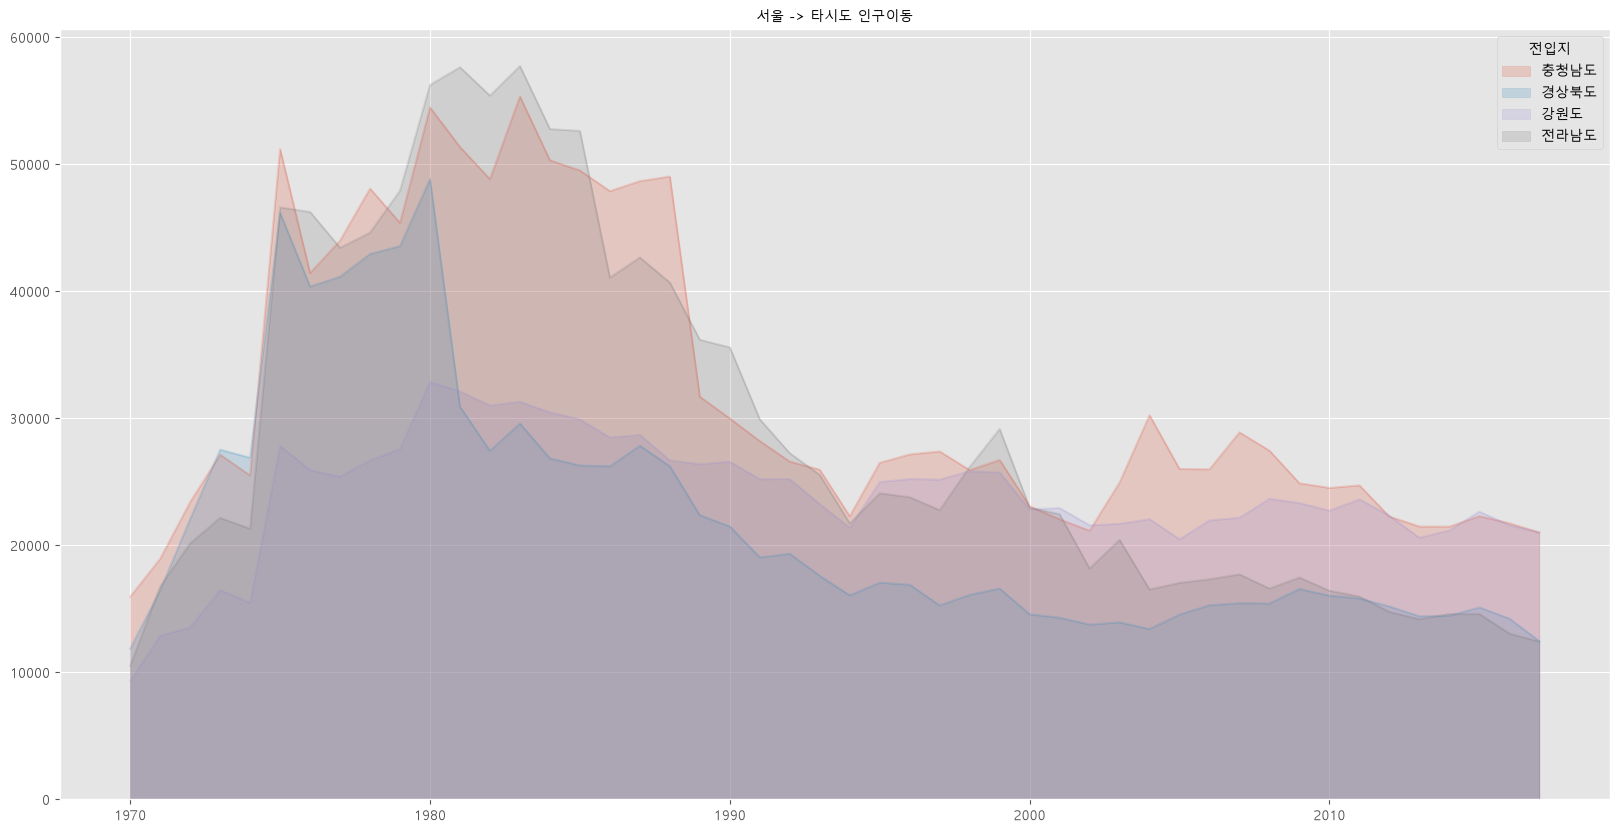

In [75]:
plt.style.use("ggplot")

df_4.plot(
    kind="area", 
    stacked=False,
    alpha=0.2,
    figsize=(20, 10)
    )

plt.title("서울 -> 타시도 인구이동", size=10)

plt.show()

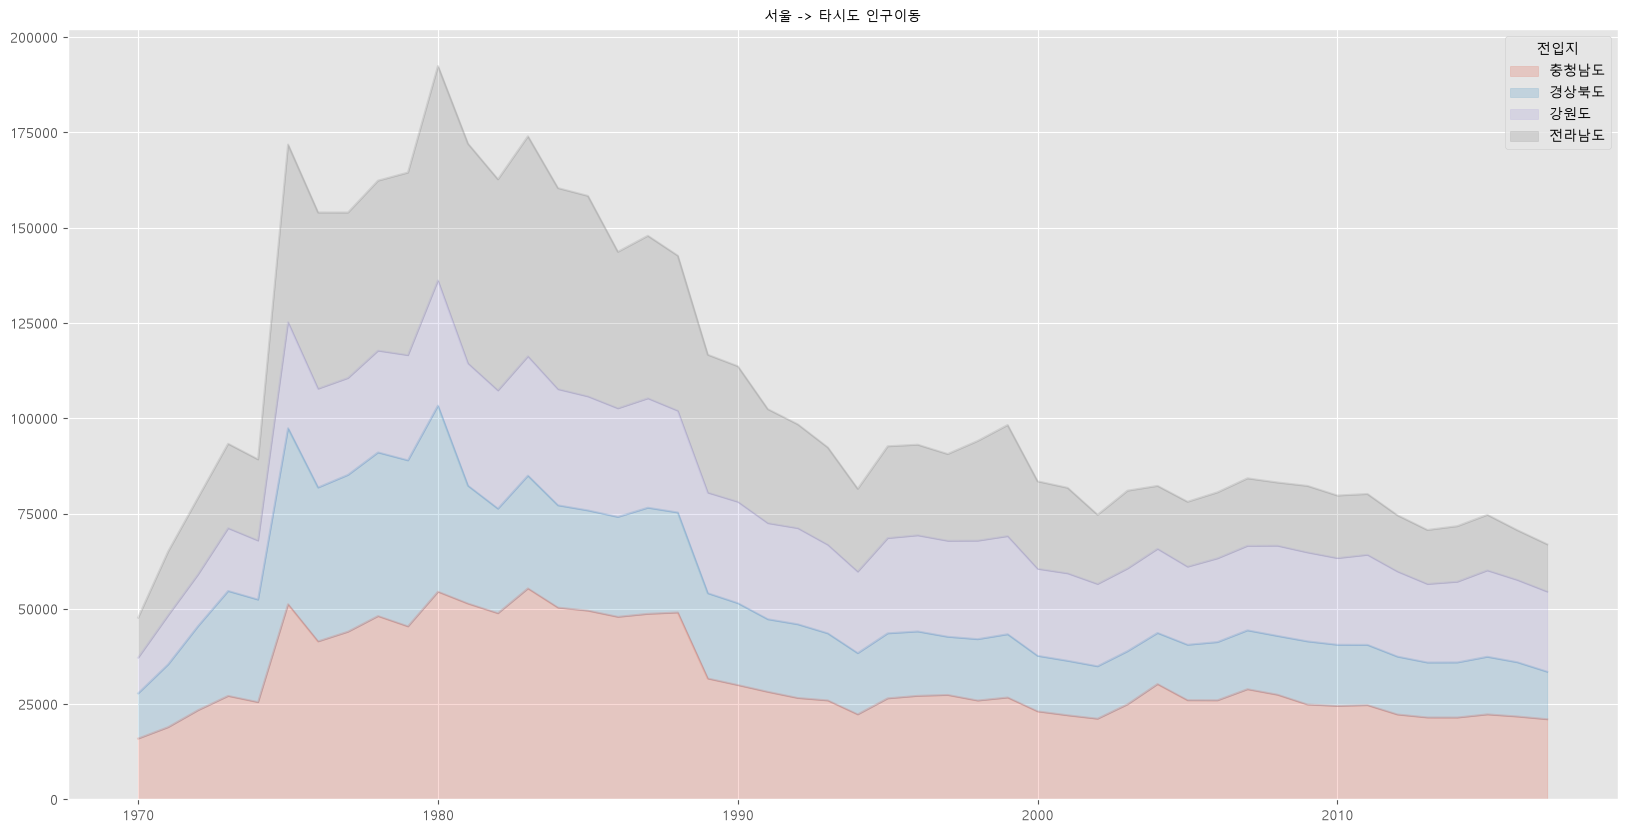

In [76]:
df_4.plot(
    kind="area", 
    stacked=True,
    alpha=0.2,
    figsize=(20, 10)
    )

plt.title("서울 -> 타시도 인구이동", size=10)

plt.show()

<class 'matplotlib.axes._axes.Axes'>


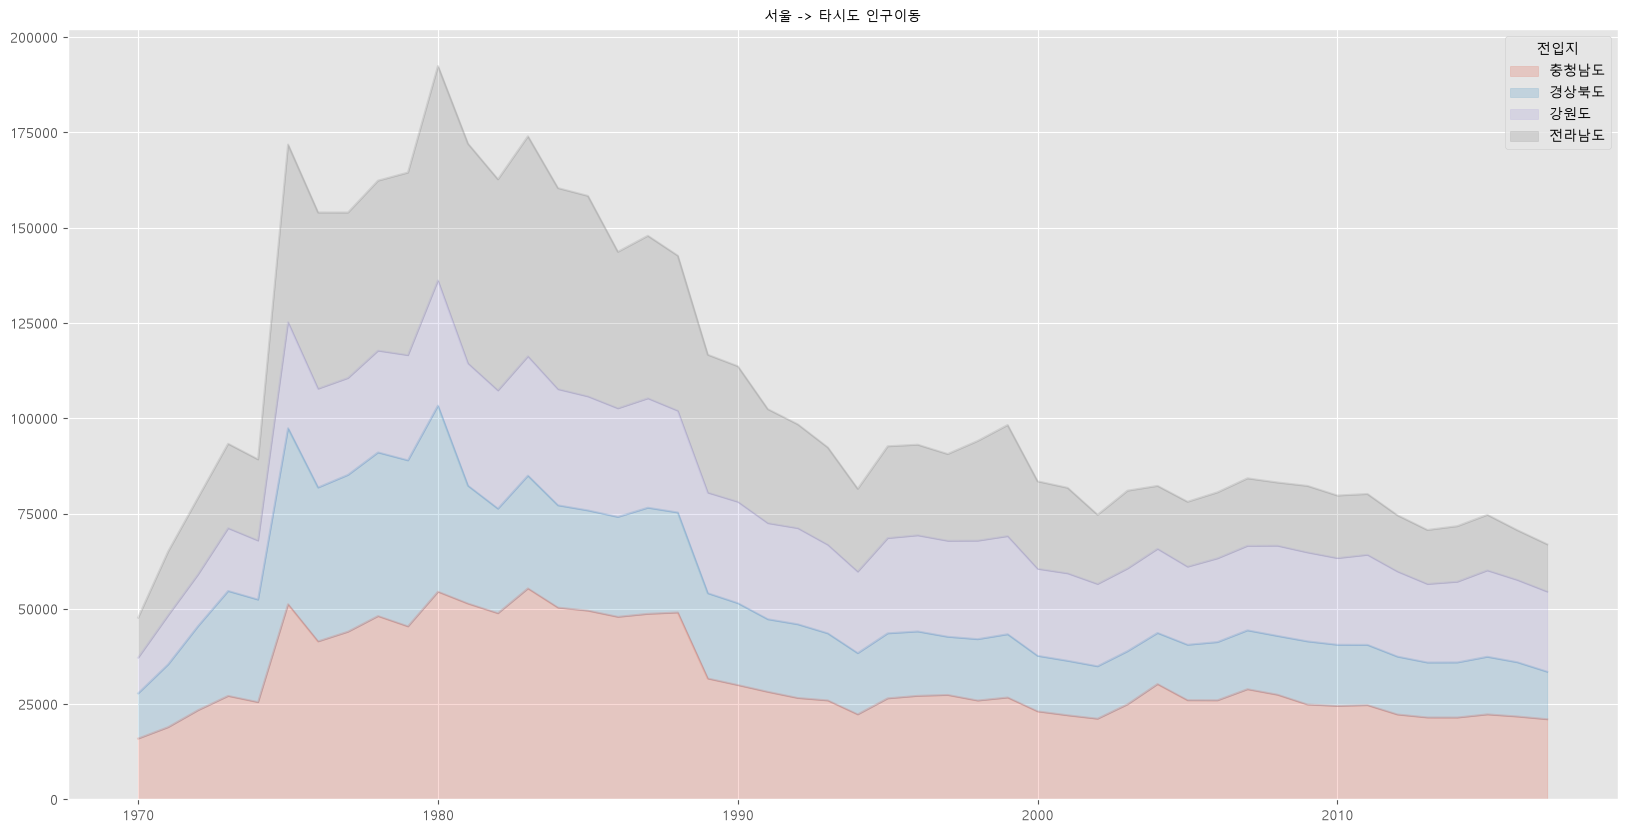

In [77]:
ax = df_4.plot(
    kind="area", 
    stacked=True,
    alpha=0.2,
    figsize=(20, 10)
    )

print(type(ax))

plt.title("서울 -> 타시도 인구이동", size=10)

plt.show()

In [81]:
df_4.index

Index(['1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978',
       '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987',
       '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996',
       '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005',
       '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014',
       '2015', '2016', '2017'],
      dtype='str')

In [85]:
# 막대그래프
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]
df_4 = df_4.T

df_4

df_4.index = df_4.index.map(int)
df_4.index

Index([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017], dtype='int64')

<Axes: >

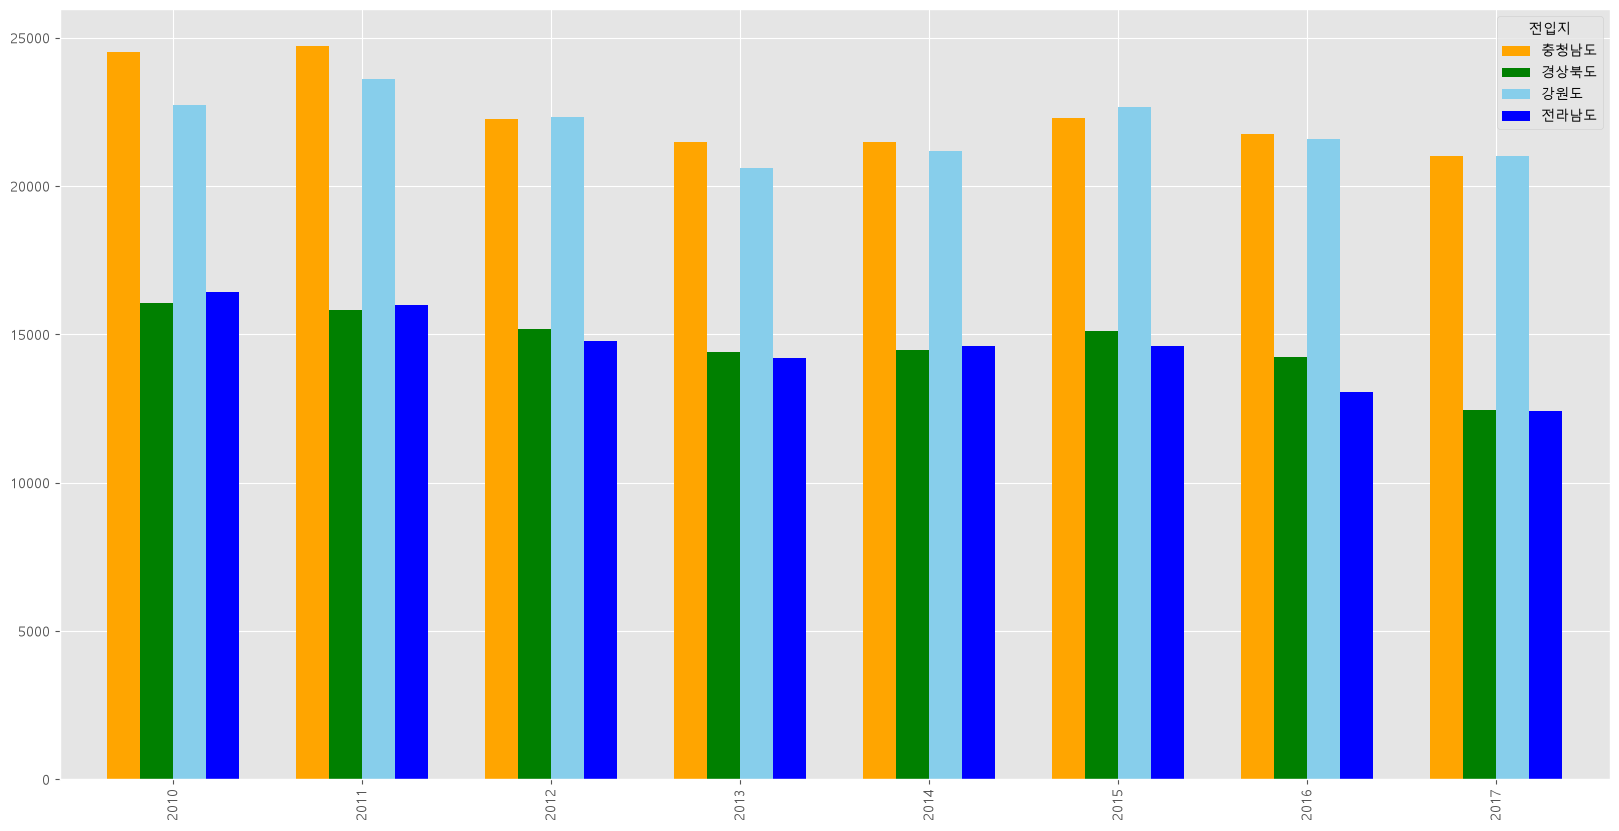

In [86]:
df_4.plot(
    kind="bar",
    figsize=(20, 10),
    width=0.7,
    color=["orange", "green", "skyblue", "blue"]
    )

In [87]:
col_years = list(map(str, range(2010, 2018)))
df_4 = df_seoul.loc[["충청남도", "경상북도", "강원도", "전라남도"], col_years]
df_4

,2010,2011,2012,2013,2014,2015,2016,2017
전입지,,,,,,,,
충청남도,24522,24723,22269,21486,21473,22299,21741,21020
경상북도,16042,15818,15191,14420,14456,15113,14236,12464
강원도,22736,23624,22332,20601,21173,22659,21590,21016
전라남도,16429,15974,14765,14187,14591,14598,13065,12426


In [92]:
df_4["합계"] = df_4.sum(axis=1)

In [93]:
df_4

,2010,2011,2012,2013,2014,2015,2016,2017,합계
전입지,,,,,,,,,
충청남도,24522,24723,22269,21486,21473,22299,21741,21020,179533
경상북도,16042,15818,15191,14420,14456,15113,14236,12464,117740
강원도,22736,23624,22332,20601,21173,22659,21590,21016,175731
전라남도,16429,15974,14765,14187,14591,14598,13065,12426,116035


In [ ]:
df_total = df_4[["합계"]].sort_values(by="합계", ascending=True)


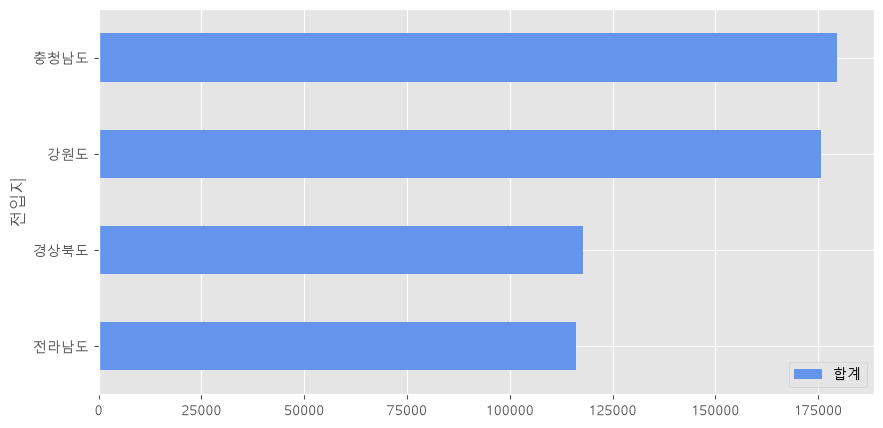

In [96]:
df_total.plot(kind="barh", color="cornflowerblue", width = 0.5, figsize=(10, 5))

plt.show()

In [105]:
# 2축 그래프

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

# 한글 폰드 세팅
font_path = ("./data/malgun.ttf")
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)

plt.style.use("ggplot")
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_excel("./data/남북한발전전력량.xlsx")
df = df.loc[5:9]
df.drop("전력량 (억㎾h)", axis="columns", inplace=True)
df

,발전 전력별,1990,1991,1992,1993,1994,1995,1996,1997,1998,...,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016
5,합계,277,263,247,221,231,230,213,193,170,...,236,255,235,237,211,215,221,216,190,239
6,수력,156,150,142,133,138,142,125,107,102,...,133,141,125,134,132,135,139,130,100,128
7,화력,121,113,105,88,93,88,88,86,68,...,103,114,110,103,79,80,82,86,90,111
8,원자력,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
